In [4]:
from uphate.nn import TransformerConfig, Transformer
from phate import PHATE
from phate.tree import gen_dla
from flax import nnx
import jax
import jax.numpy as jnp
import orbax.checkpoint as ocp

import matplotlib.pyplot as plt

In [5]:
emb_dir = "../embeddings/dla_12122025_121654/"
l = jnp.load(emb_dir + "labels.npy")
X = jnp.load(emb_dir + "X.npy")
X_phate = jnp.load(emb_dir + "X_phate.npy")
X_surrogate = jnp.load(emb_dir + "X_surrogate.npy")
jac_surrogate = jnp.load(emb_dir + "jac_surrogate.npy")

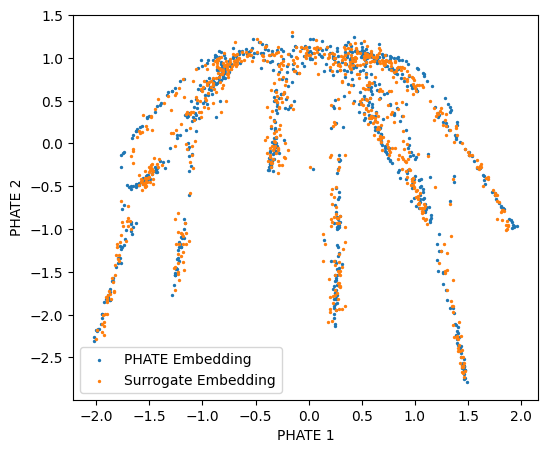

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
s1 = ax.scatter(*X_phate.T, s=2, label="PHATE Embedding")
s2 = ax.scatter(*X_surrogate.T, s=2, label="Surrogate Embedding")
ax.legend()
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
fig.savefig("../figures/phate_surrogate_overlay.png")

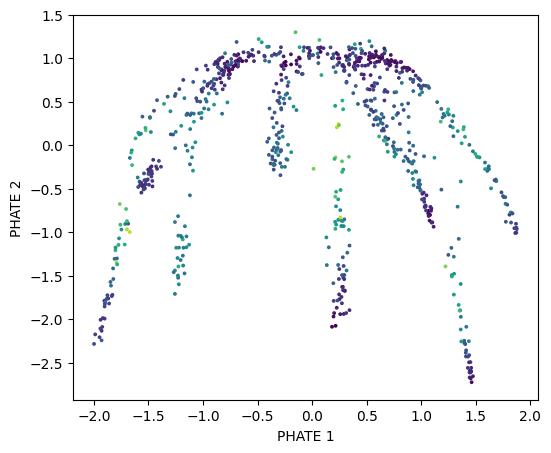

In [ ]:
gradient_magnitudes = jnp.linalg.norm(jac_surrogate, axis=(2, 3))
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(*X_surrogate.T, c=jnp.log(jnp.linalg.norm(gradient_magnitudes, axis=1)), s=3)
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
fig.savefig("../figures/surrogate_gradient_magnitudes.png")

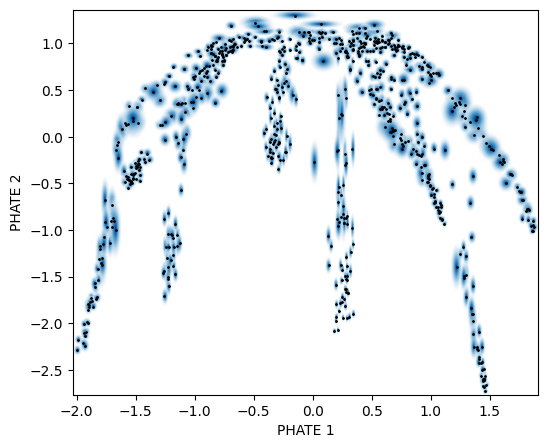

In [ ]:
from uphate.plotting import plot_ellipses_with_sprites

fig, ax = plot_ellipses_with_sprites(X_surrogate, gradient_magnitudes * 0.2, (6, 5))
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
fig.savefig("../figures/surrogate_gradient_ellipses.png")